# Storytelling com Dados: Prevendo a Satisfação do Cliente no E-commerce

Neste notebook, vamos explorar uma base de dados de um e-commerce com o objetivo de entender
**quais fatores operacionais influenciam a satisfação do cliente medida pelo NPS **.

Ao longo da análise, seguiremos as seguintes etapas:

1. Entendimento do problema de negócio
2. Definição da variável-alvo (target)
3. Qualidade e estrutura dos dados
4. Panorama geral do NPS
5. Perfil do cliente: idade, região e tempo de relacionamento
6. Operação logística: o que acontece entre a compra e a entrega
7. Atendimento e reclamações
8. CSAT interno e recompra
9. Conclusão

## 1. Entendimento do problema de negócio


### Qual problema estamos resolvendo?

Uma empresa de e-commerce em crescimento percebeu que clientes com indicadores operacionais semelhantes
(mesmo tempo de entrega, mesmo valor de pedido, etc.) acabam se tornando **promotores** ou **detratores**
da marca. Hoje, o NPS é coletado **apenas após o encerramento da jornada de compra**, o que limita a
capacidade da empresa de antecipar problemas e agir preventivamente.

A pergunta central é: **quais fatores operacionais realmente influenciam a satisfação do cliente
e como a empresa pode agir antes da pesquisa de NPS?**



## 2. Definição da variável-alvo (target)


### Qual variável representa a satisfação do cliente?

A variável deste problema é a coluna **`nps_score`**, que registra a nota dada pelo cliente
após a experiência de compra, em uma escala contínua de 0 a 10.

A partir dela, realizei a categorização do NPS:

- **Detratores**: notas de 0 a 6 (clientes insatisfeitos)
- **Neutros**: notas 7 e 8 (satisfeitos, mas não engajados)
- **Promotores**: notas 9 e 10 (clientes leais, geram recompra e indicações)


### Em que momento da jornada a informação é coletada?

A pesquisa é aplicada **após o encerramento da jornada de compra** (entrega + eventual atendimento).
Essa é justamente a limitação que motiva o projeto: o NPS chega tarde, quando a experiência ruim
**já aconteceu**.



## 3. Carregamento dos dados e checagem de qualidade


In [58]:

# Imports e Configuração
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

from src.data_cleaning import load_raw_data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
# Lendo o Arquivo CSV
df = load_raw_data('desafio_nps_fase_1.csv')
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9


In [60]:
# Estrutura geral da base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                2500 non-null   int64  
 1   customer_age               2500 non-null   int64  
 2   customer_region            2500 non-null   object 
 3   customer_tenure_months     2500 non-null   int64  
 4   order_id                   2500 non-null   int64  
 5   order_value                2500 non-null   float64
 6   items_quantity             2500 non-null   int64  
 7   discount_value             2500 non-null   float64
 8   payment_installments       2500 non-null   int64  
 9   delivery_time_days         2500 non-null   int64  
 10  delivery_delay_days        2500 non-null   int64  
 11  freight_value              2500 non-null   float64
 12  delivery_attempts          2500 non-null   int64  
 13  customer_service_contacts  2500 non-null   int64

In [61]:
# Verificação de valores nulos
df.isnull().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
dtype: int64

In [62]:
# Estatísticas descritivas das variáveis numéricas
df.describe().round(2)

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,1250.50,43.40,61.32,51250.50,434.26,3.47,29.75,6.00,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.00,18.00,1.00,50001.00,7.76,1.00,0.02,1.00,2.00,0.00,2.62,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,625.75,31.00,31.00,50625.75,220.24,2.00,8.88,3.00,5.00,1.00,29.93,1.00,1.00,2.00,2.60,0.00,3.00,0.70
50%,1250.50,43.00,62.00,51250.50,375.52,3.00,20.94,6.00,8.00,2.00,38.50,2.00,1.00,6.00,4.40,0.00,4.00,2.80
75%,1875.25,56.00,91.00,51875.25,577.29,5.00,40.83,9.00,11.00,3.00,46.27,3.00,2.00,8.00,6.10,0.00,5.00,4.80
max,2500.00,69.00,119.00,52500.00,1983.81,6.00,230.33,11.00,14.00,8.00,76.13,3.00,7.00,11.00,10.00,1.00,11.00,10.00


**Checagem de qualidade:**

- Base com **2.500 linhas e 19 colunas**, todas preenchidas e sem valore nulos.

## Painel de correlações: a hierarquia de fatores


Testando hipoteses iniciais

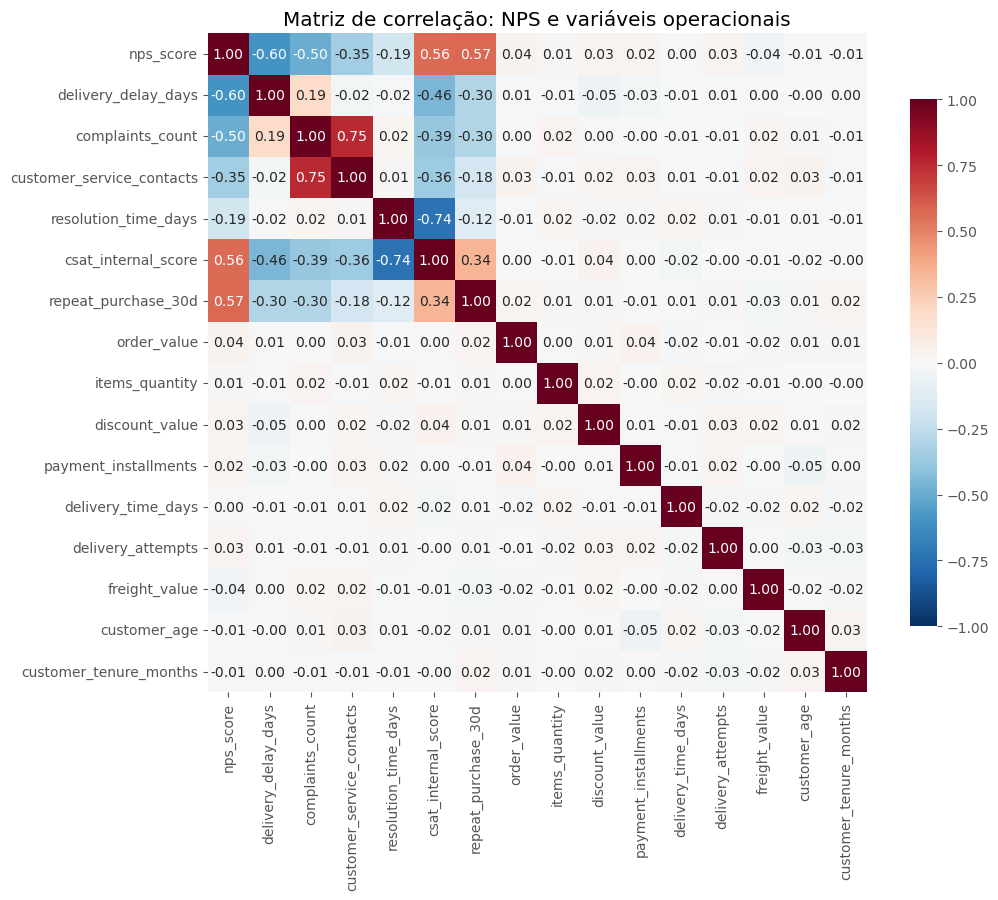

In [88]:
# Matriz de correlação completa

vars_analise = ['nps_score','delivery_delay_days','complaints_count','customer_service_contacts',
                'resolution_time_days','csat_internal_score','repeat_purchase_30d',
                'order_value','items_quantity','discount_value','payment_installments',
                'delivery_time_days','delivery_attempts','freight_value',
                'customer_age','customer_tenure_months']

corr = df[vars_analise].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'shrink': 0.8})
plt.title('Matriz de correlação: NPS e variáveis operacionais')
plt.tight_layout()
plt.show()

/var/folders/rh/vq3_x16j5c3c0xs3x73_hnlr0000gn/T/ipykernel_57498/2273815513.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=correlacoes_nps.values, y=correlacoes_nps.index, palette=cores_barras)


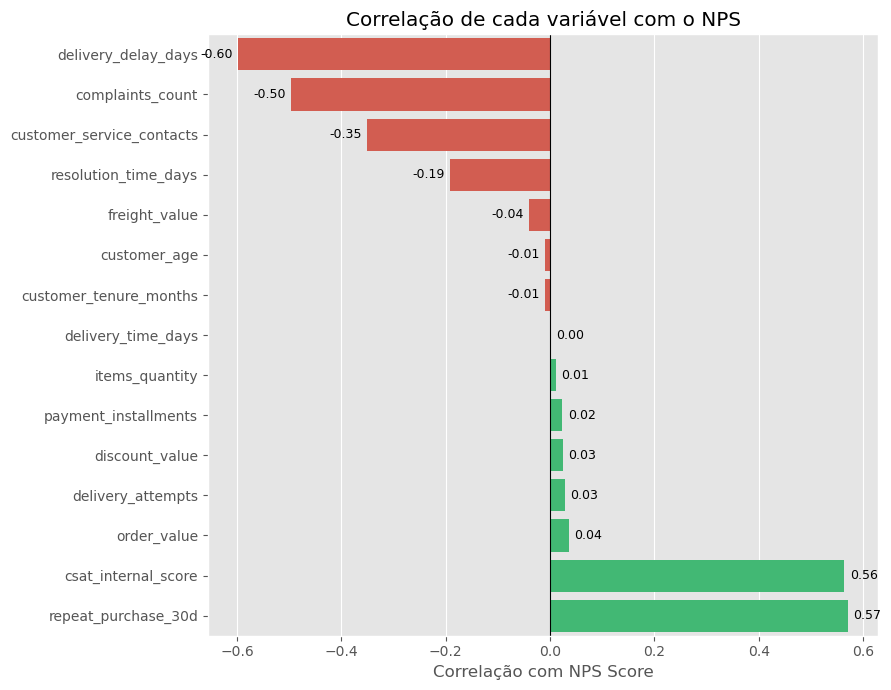

In [89]:
# Ranking dos fatores que mais impactam o NPS

correlacoes_nps = df[vars_analise].corr()['nps_score'].drop('nps_score').sort_values()

plt.figure(figsize=(9, 7))
cores_barras = ['#e74c3c' if c < 0 else '#2ecc71' for c in correlacoes_nps.values]
ax = sns.barplot(x=correlacoes_nps.values, y=correlacoes_nps.index, palette=cores_barras)
for i, v in enumerate(correlacoes_nps.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f'{v:.2f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)
plt.title('Correlação de cada variável com o NPS')
plt.xlabel('Correlação com NPS Score')
plt.ylabel('')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()



A matriz e o ranking já demostra os principais pontos de correlação e vou me basenar nelas para construir o storytelling:

**Top 3 destruidores de NPS (correlação negativa forte):**

1. `delivery_delay_days` — atraso na entrega (-0,60)
2. `complaints_count` — número de reclamações (-0,50)
3. `customer_service_contacts` — contatos com SAC (-0,35)

**Top 2 sustentadores de NPS (correlação positiva forte):**

1. `repeat_purchase_30d` — recompra em 30 dias (+0,57)
2. `csat_internal_score` — CSAT interno (+0,56)

**Variáveis com baixíssimo impacto** (correlação próxima de zero): valor do pedido, idade, região,
tempo de relacionamento, tempo total de entrega, parcelamento, desconto, frete, quantidade de itens.

Isso significa que **a empresa não precisa segmentar a operação por perfil de cliente** para melhorar
o NPS. Precisa **arrumar a operação** para todos os clientes simultaneamente.

## 4. Panorama geral do NPS

*como o NPS está distribuído entre os clientes da empresa?**


- Observar a distribuição da nota de NPS (histograma e boxplot)
- Calcular medidas de tendência central
- Categorizar os clientes em Detratores, Neutros e Promotores
- Calcular o **NPS Score consolidado** do negócio


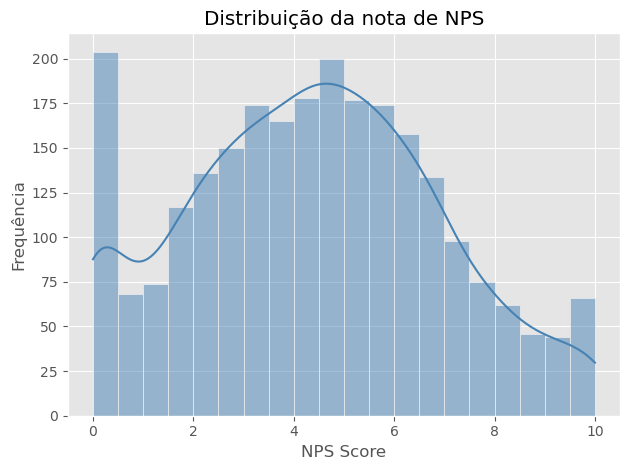

In [63]:
#Histograma do NPS

sns.histplot(df['nps_score'], bins=20, kde=True, color='steelblue')
plt.title('Distribuição da nota de NPS')
plt.xlabel('NPS Score')
plt.ylabel('Frequência')
plt.tight_layout()

plt.show()

Detratores (0-6): Clientes insatisfeitos.

Passivos/Neutros (7-8): Clientes satisfeitos

Promotores (9-10): Clientes engajados

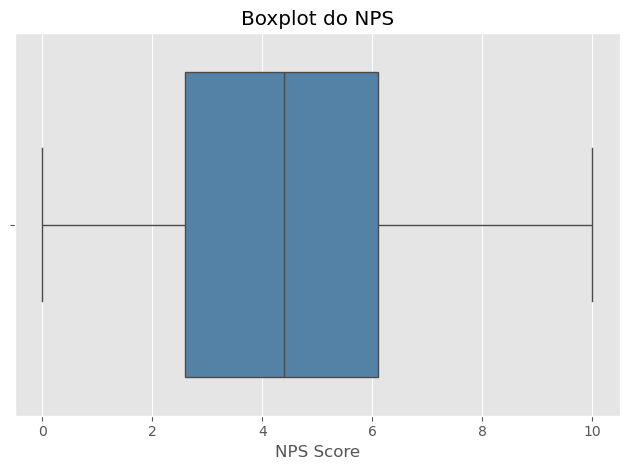

In [64]:
#Boxplot

sns.boxplot(x=df['nps_score'], color='steelblue')
plt.title('Boxplot do NPS')
plt.xlabel('NPS Score')
plt.tight_layout()

plt.show()

Esse ponto chama a atenção, porque dentro a linha central dento da caixa está posicionada em 4.5 (mediana), ou seja, **mais de 50% dão uma nota inferior a 5**.

In [65]:
#Medidas resumo do NPS
df['nps_score'].agg(['mean','median','min','max','std']).round(2)



mean       4.38
median     4.40
min        0.00
max       10.00
std        2.51
Name: nps_score, dtype: float64

**Conversão da nota do NPS em categorias, já identificadas mais acima**

In [66]:
def categorize_nps(score):
    if score >= 9:
        return 'Promotor'
    elif score >= 7:
        return 'Neutro'
    else:
        return 'Detrator'

df['nps_categoria'] = df['nps_score'].apply(categorize_nps)

# Distribuição percentual
distribuicao = df['nps_categoria'].value_counts(normalize=True).mul(100).round(1)
distribuicao = distribuicao.reindex(['Promotor','Neutro','Detrator'])
distribuicao

nps_categoria
Promotor     4.4
Neutro      11.2
Detrator    84.4
Name: proportion, dtype: float64

/var/folders/rh/vq3_x16j5c3c0xs3x73_hnlr0000gn/T/ipykernel_57498/2348099657.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=distribuicao.index, y=distribuicao.values,


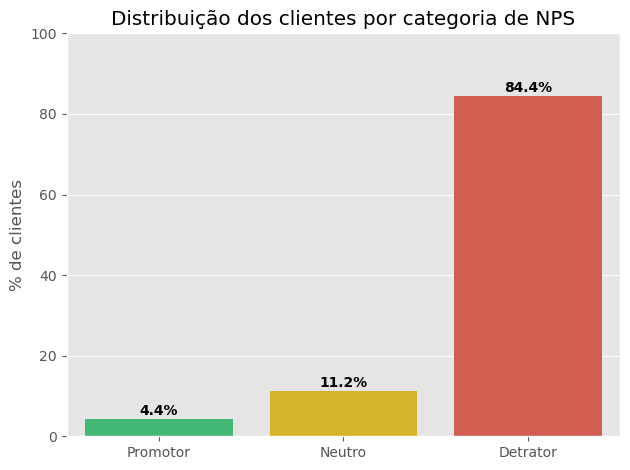

In [67]:
#Visualização da distribuição de categorias

cores = {'Promotor':'#2ecc71', 'Neutro':'#f1c40f', 'Detrator':'#e74c3c'}

ax = sns.barplot(x=distribuicao.index, y=distribuicao.values,
                 palette=[cores[c] for c in distribuicao.index])

for i, v in enumerate(distribuicao.values):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.title('Distribuição dos clientes por categoria de NPS')
plt.ylabel('% de clientes')
plt.xlabel('')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [90]:
#Cálculo do NPS Score consolidado

pct_promotores = (df['nps_categoria'] == 'Promotor').mean() * 100
pct_detratores = (df['nps_categoria'] == 'Detrator').mean() * 100
nps_score_final = pct_promotores - pct_detratores

print(f'% Promotores: {pct_promotores:.1f}%')
print(f'% Detratores: {pct_detratores:.1f}%')
print(f'NPS Score consolidado: {nps_score_final:.1f}')

% Promotores: 4.4%
% Detratores: 84.4%
NPS Score consolidado: -80.0


### Conclusão


- A média e mediana de NPS é **4,4**— bem abaixo do que se espera de um e-commerce saudável.
- **84,4% dos clientes são detratores** (notas 0-6), apenas **4,4% são promotores**.
- O **NPS Score consolidado é de aproximadamente -80**: Para referência, segundo benchmarks de mercado, um NPS positivo já é considerado bom e acima de 50
é considerado excelente. Um NPS de -80 indica uma operação com problemas.

A pergunta agora é: **o que está fazendo esses clientes virarem detratores?** É isso que vamos investigar
nas próximas seções.

## 5. Perfil do cliente: idade, região e tempo de relacionamento

Antes de olhar a operação (logística), vamos verificar se **o perfil do cliente** explica
parte da variação do NPS. Pode ser que clientes mais velhos sejam mais críticos? Que clientes de uma região
específica sejam piores? Que clientes mais antigos sejam mais leais?


In [68]:
# NPS por região

nps_regiao = df.groupby('customer_region')['nps_score'].agg(['mean','median','count']).round(2)
nps_regiao = nps_regiao.sort_values('mean', ascending=False)
nps_regiao

,mean,median,count
customer_region,,,
Sul,4.49,4.5,521
Nordeste,4.42,4.5,485
Norte,4.38,4.5,506
Sudeste,4.37,4.3,520
Centro-Oeste,4.21,4.2,468


/var/folders/rh/vq3_x16j5c3c0xs3x73_hnlr0000gn/T/ipykernel_57498/1915864459.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nps_regiao.index, y=nps_regiao['mean'], palette='Blues_d')


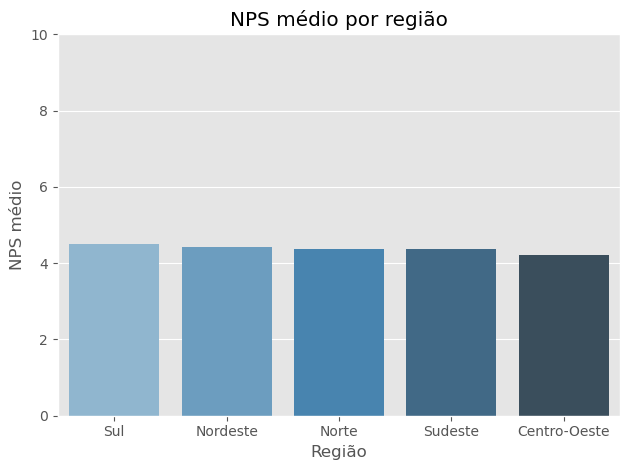

In [69]:
#Gráfico do NPS médio por região

plt.figure()
sns.barplot(x=nps_regiao.index, y=nps_regiao['mean'], palette='Blues_d')
plt.title('NPS médio por região')
plt.xlabel('Região')
plt.ylabel('NPS médio')
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

O NPS é simialr entre as regiões

/var/folders/rh/vq3_x16j5c3c0xs3x73_hnlr0000gn/T/ipykernel_57498/1982018697.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='customer_region', y='nps_score',


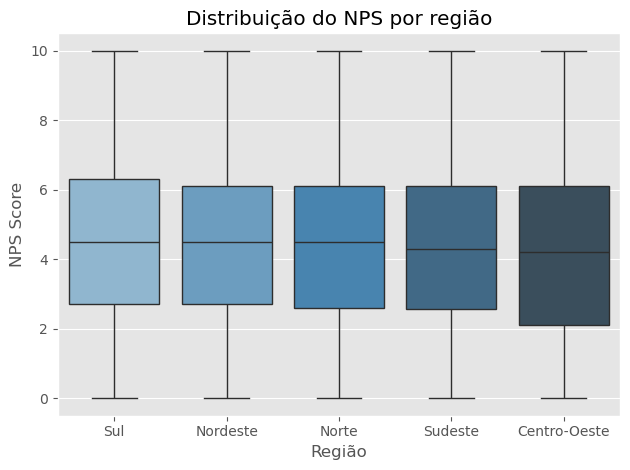

In [70]:
# Boxplot por região

plt.figure()
sns.boxplot(data=df, x='customer_region', y='nps_score',
            order=nps_regiao.index, palette='Blues_d')
plt.title('Distribuição do NPS por região')
plt.xlabel('Região')
plt.ylabel('NPS Score')
plt.tight_layout()
plt.show()

A região Sul apresenta uma mediana levemente superior, mas ainda assim estritamente dentro da zona de detração.

In [71]:
# NPS por faixa etária

df['faixa_etaria'] = pd.cut(df['customer_age'],
                            bins=[17, 25, 35, 50, 70],
                            labels=['18-25','26-35','36-50','51-69'])

nps_idade = df.groupby('faixa_etaria', observed=True)['nps_score'].agg(['mean','count']).round(2)
nps_idade

,mean,count
faixa_etaria,,
18-25,4.48,389
26-35,4.56,465
36-50,4.19,747
51-69,4.40,899


In [72]:
# NPS por tempo de relacionamento

df['faixa_tenure'] = pd.cut(df['customer_tenure_months'],
                            bins=[-1, 6, 12, 24, 60, 200],
                            labels=['Até 6m','6-12m','1-2 anos','2-5 anos','5+ anos'])

nps_tenure = df.groupby('faixa_tenure', observed=True)['nps_score'].agg(['mean','count']).round(2)
nps_tenure

,mean,count
faixa_tenure,,
Até 6m,4.17,122
6-12m,4.12,120
1-2 anos,4.65,247
2-5 anos,4.35,721
5+ anos,4.39,1290


/var/folders/rh/vq3_x16j5c3c0xs3x73_hnlr0000gn/T/ipykernel_57498/2486136796.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nps_idade.index, y=nps_idade['mean'], palette='Purples_d', ax=axes[0])
/var/folders/rh/vq3_x16j5c3c0xs3x73_hnlr0000gn/T/ipykernel_57498/2486136796.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nps_tenure.index, y=nps_tenure['mean'], palette='Greens_d', ax=axes[1])


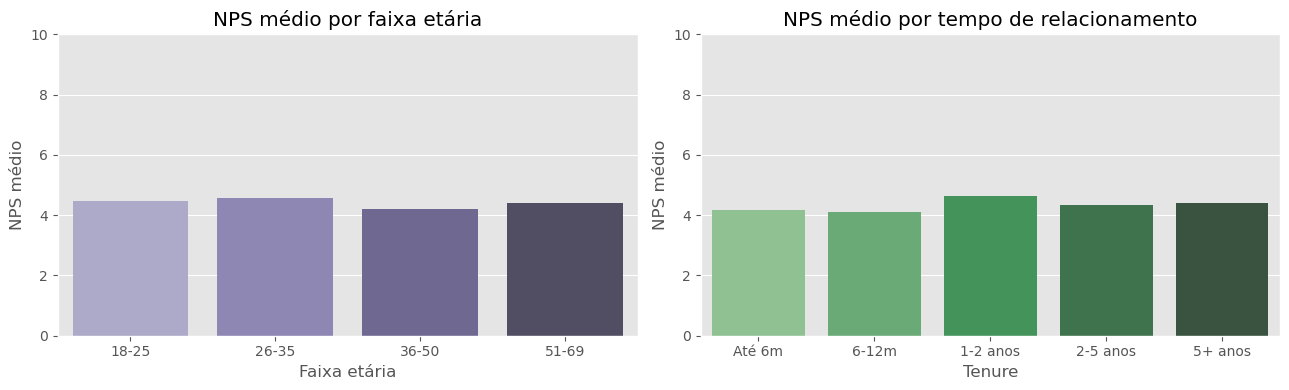

In [73]:
#Visualização lado a lado

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(x=nps_idade.index, y=nps_idade['mean'], palette='Purples_d', ax=axes[0])
axes[0].set_title('NPS médio por faixa etária')
axes[0].set_xlabel('Faixa etária')
axes[0].set_ylabel('NPS médio')
axes[0].set_ylim(0, 10)

sns.barplot(x=nps_tenure.index, y=nps_tenure['mean'], palette='Greens_d', ax=axes[1])
axes[1].set_title('NPS médio por tempo de relacionamento')
axes[1].set_xlabel('Tenure')
axes[1].set_ylabel('NPS médio')
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.show()

### Conclusão

**o perfil do cliente não explica a variação do NPS**.

- Por **região**, todas ficam entre 4,21 (Centro-Oeste) e 4,49 (Sul). Diferença de menos de 0,3 ponto.
- Por **faixa etária**, o NPS é praticamente plano em todas as faixas.
- Por **tempo de relacionamento**, também, clientes novos e antigos têm satisfação parecida.


## 6. Operação logística:

Se o perfil do cliente não explica o NPS baixo, a próxima hipótese natural é a operação.

Vamos analisar:

- `delivery_time_days` (tempo total de entrega)
- `delivery_delay_days` (atraso em relação ao prometido)
- `delivery_attempts` (tentativas de entrega)
- `freight_value` (valor do frete)

In [74]:
# Correlação dessas variáveis com o NPS

vars_logistica = ['delivery_time_days','delivery_delay_days',
                  'delivery_attempts','freight_value']
correlacoes_log = df[vars_logistica + ['nps_score']].corr()['nps_score'].drop('nps_score').round(2)
correlacoes_log.sort_values()

delivery_delay_days   -0.60
freight_value         -0.04
delivery_time_days     0.00
delivery_attempts      0.03
Name: nps_score, dtype: float64

In [75]:
#NPS por faixa de atraso

df['faixa_atraso'] = pd.cut(df['delivery_delay_days'],
                            bins=[-1, 0, 3, 7, 30],
                            labels=['No prazo','1-3 dias','4-7 dias','8+ dias'])

nps_atraso = df.groupby('faixa_atraso', observed=True)['nps_score'].agg(['mean','count']).round(2)
nps_atraso

,mean,count
faixa_atraso,,
No prazo,6.86,277
1-3 dias,4.58,1786
4-7 dias,2.01,434
8+ dias,0.00,3


/var/folders/rh/vq3_x16j5c3c0xs3x73_hnlr0000gn/T/ipykernel_57498/1719656657.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=nps_atraso.index, y=nps_atraso['mean'],


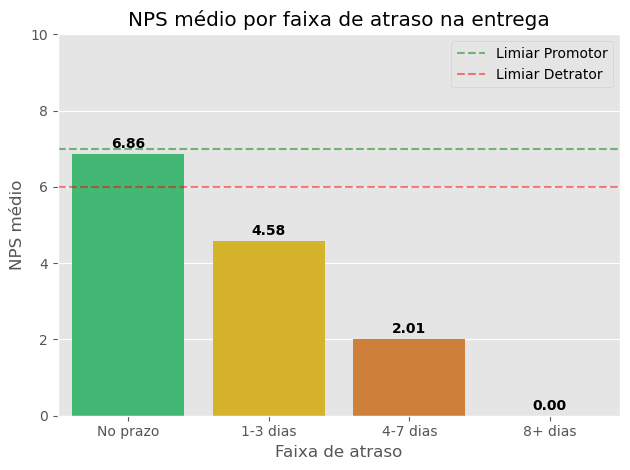

In [76]:
# NPS médio por faixa de atraso

plt.figure()
ax = sns.barplot(x=nps_atraso.index, y=nps_atraso['mean'],
                 palette=['#2ecc71','#f1c40f','#e67e22','#e74c3c'])
for i, v in enumerate(nps_atraso['mean'].values):
    ax.text(i, v + 0.15, f'{v:.2f}', ha='center', fontweight='bold')
plt.title('NPS médio por faixa de atraso na entrega')
plt.xlabel('Faixa de atraso')
plt.ylabel('NPS médio')
plt.ylim(0, 10)
plt.axhline(y=7, color='green', linestyle='--', alpha=0.5, label='Limiar Promotor')
plt.axhline(y=6, color='red', linestyle='--', alpha=0.5, label='Limiar Detrator')
plt.legend()
plt.tight_layout()
plt.show()

Com apenas 72 horas de atraso, perdemos 33% do valor de satisfação.

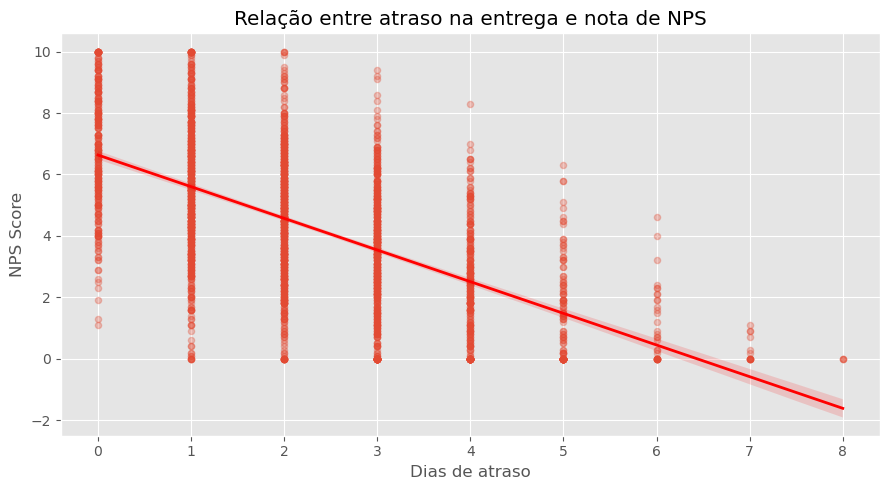

In [77]:
# Scatter plot: atraso x NPS

plt.figure(figsize=(9, 5))
sns.regplot(data=df, x='delivery_delay_days', y='nps_score',
            scatter_kws={'alpha': 0.3, 's': 20},
            line_kws={'color':'red', 'linewidth': 2})
plt.title('Relação entre atraso na entrega e nota de NPS')
plt.xlabel('Dias de atraso')
plt.ylabel('NPS Score')
plt.tight_layout()
plt.show()

Até o 2º dia de atraso, a nota média ainda flutua em torno de 4 a 5. A partir do 3º dia, a dispersão diminui e os pontos se concentram na base do gráfico.

O 3º dia parece ser o limite do consumidor. Após esse marco, a chance de obter um "Promotor" (nota 9-10) torna-se estatisticamente BAIXA. reforçando a visão anterior

/var/folders/rh/vq3_x16j5c3c0xs3x73_hnlr0000gn/T/ipykernel_57498/42252283.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nps_entrega.index, y=nps_entrega.values, palette='Blues_d', ax=axes[0])
/var/folders/rh/vq3_x16j5c3c0xs3x73_hnlr0000gn/T/ipykernel_57498/42252283.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nps_atraso.index, y=nps_atraso['mean'],


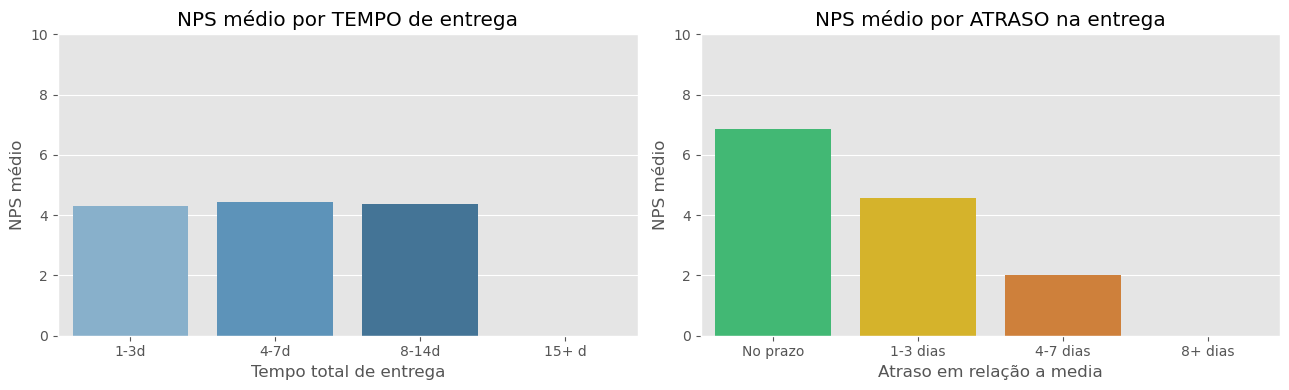

In [78]:
#Comparativo: tempo de entrega vs. atraso na entrega

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Tempo de entrega
df['faixa_entrega'] = pd.cut(df['delivery_time_days'],
                             bins=[0, 3, 7, 14, 30],
                             labels=['1-3d','4-7d','8-14d','15+ d'])
nps_entrega = df.groupby('faixa_entrega', observed=True)['nps_score'].mean()

sns.barplot(x=nps_entrega.index, y=nps_entrega.values, palette='Blues_d', ax=axes[0])
axes[0].set_title('NPS médio por TEMPO de entrega')
axes[0].set_xlabel('Tempo total de entrega')
axes[0].set_ylabel('NPS médio')
axes[0].set_ylim(0, 10)

# Atraso (já calculado)
sns.barplot(x=nps_atraso.index, y=nps_atraso['mean'],
            palette=['#2ecc71','#f1c40f','#e67e22','#e74c3c'], ax=axes[1])
axes[1].set_title('NPS médio por ATRASO na entrega')
axes[1].set_xlabel('Atraso em relação a media')
axes[1].set_ylabel('NPS médio')
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.show()

### Conclusão

- **O tempo total de entrega quase não influencia o NPS** (correlação de 0,001). Pedidos entregues em
  3 dias ou em 14 dias têm NPS médio parecido.
- **O atraso, sim, é devastador** (correlação de -0,60, a mais forte de toda a base).

A diferença entre as duas variáveis é a chave do insight:

| Atraso | NPS médio |
|--------|-----------|
| No prazo | 6,86 (próximo de neutro/promotor) |
| 1-3 dias de atraso | 4,58 (detrator) |
| 4-7 dias de atraso | 2,01 (detrator severo) |
| 8+ dias de atraso | 0,00 (zero absoluto) |

Existe um **ponto de ruptura claro**: a partir de qualquer atraso, o NPS desaba. O cliente não está
medindo "quantos dias demorou", está medindo "**a empresa cumpriu o que prometeu?**". Esse é um insight
acionável: o investimento em **previsibilidade do prazo** (mesmo que seja um prazo maior, mas honesto)
pode ter mais impacto do que reduzir o tempo absoluto de entrega.

As demais variáveis logísticas (tentativas de entrega, valor do frete) têm correlação fraca com o NPS.

## 7. Atendimento e reclamações: a voz do cliente insatisfeito


Variáveis ligadas a
atendimento e reclamações:

- `customer_service_contacts` (número de contatos com o atendimento)
- `resolution_time_days` (tempo de resolução)
- `complaints_count` (número de reclamações)

A hipótese é: quanto mais o cliente precisa "correr atrás" da empresa, pior fica a experiência.

In [79]:
# Correlação dessas variáveis com NPS

vars_atendimento = ['customer_service_contacts','resolution_time_days','complaints_count']
correlacoes_at = df[vars_atendimento + ['nps_score']].corr()['nps_score'].drop('nps_score').round(3)
correlacoes_at.sort_values()

complaints_count            -0.497
customer_service_contacts   -0.351
resolution_time_days        -0.191
Name: nps_score, dtype: float64

In [80]:
# 8.2 NPS por número de reclamações

nps_complaints = df.groupby('complaints_count')['nps_score'].agg(['mean','count']).round(2)
nps_complaints

,mean,count
complaints_count,,
0,8.52,23
1,7.77,122
2,6.05,277
3,4.91,507
4,4.22,600
5,3.65,444
6,3.06,266
7,2.81,169
8,2.07,63


/var/folders/rh/vq3_x16j5c3c0xs3x73_hnlr0000gn/T/ipykernel_57498/1998742434.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=nps_complaints.index.astype(int), y=nps_complaints['mean'],


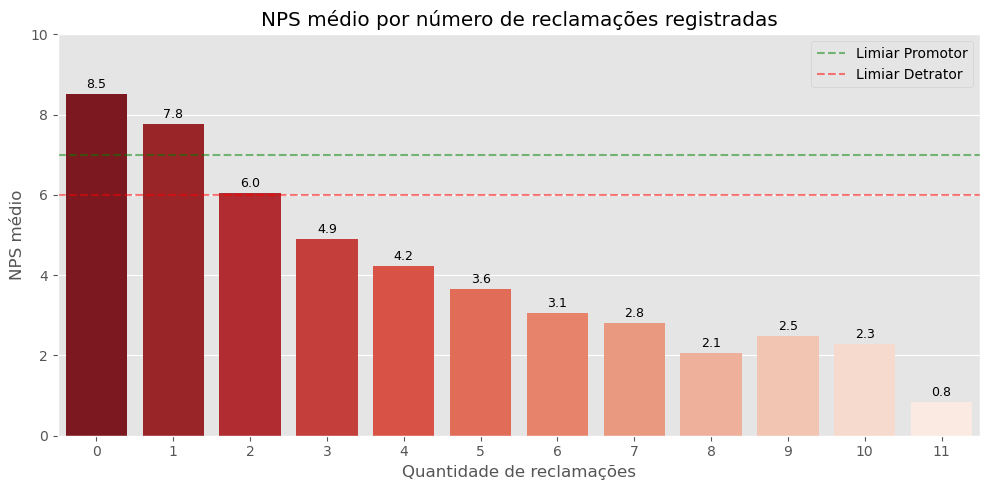

In [81]:
# NPS médio por número de reclamações

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=nps_complaints.index.astype(int), y=nps_complaints['mean'],
                 palette='Reds_r')
for i, v in enumerate(nps_complaints['mean'].values):
    ax.text(i, v + 0.15, f'{v:.1f}', ha='center', fontsize=9)
plt.title('NPS médio por número de reclamações registradas')
plt.xlabel('Quantidade de reclamações')
plt.ylabel('NPS médio')
plt.ylim(0, 10)
plt.axhline(y=7, color='green', linestyle='--', alpha=0.5, label='Limiar Promotor')
plt.axhline(y=6, color='red', linestyle='--', alpha=0.5, label='Limiar Detrator')
plt.legend()
plt.tight_layout()
plt.show()

In [82]:
#NPS por número de contatos com atendimento

df['faixa_contatos'] = pd.cut(df['customer_service_contacts'],
                              bins=[-1, 0, 1, 3, 100],
                              labels=['Nenhum','1 contato','2-3 contatos','4+ contatos'])

nps_contatos = df.groupby('faixa_contatos', observed=True)['nps_score'].agg(['mean','count']).round(2)
nps_contatos

,mean,count
faixa_contatos,,
Nenhum,5.54,554
1 contato,4.66,816
2-3 contatos,3.82,954
4+ contatos,2.47,176


/var/folders/rh/vq3_x16j5c3c0xs3x73_hnlr0000gn/T/ipykernel_57498/1197750726.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nps_contatos.index, y=nps_contatos['mean'],
/var/folders/rh/vq3_x16j5c3c0xs3x73_hnlr0000gn/T/ipykernel_57498/1197750726.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=nps_resol.index, y=nps_resol.values, palette='Reds_r', ax=axes[1])


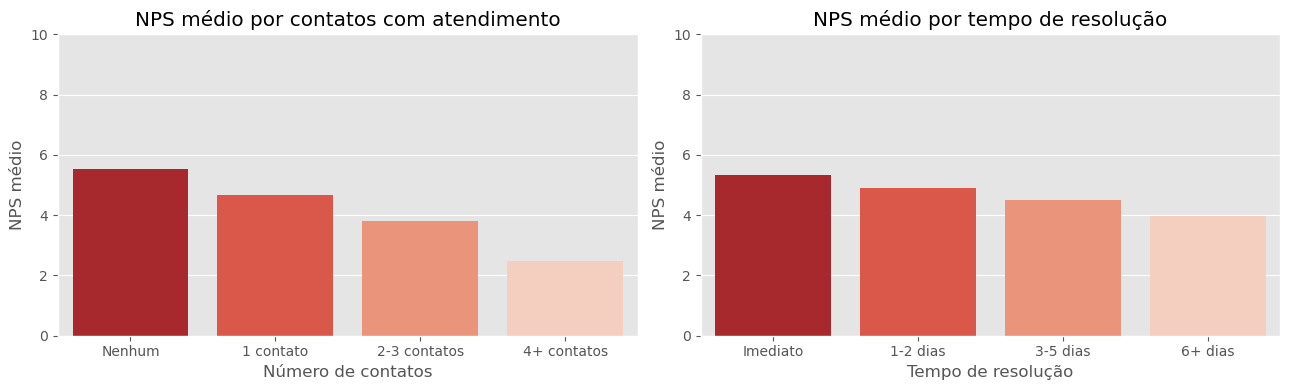

In [83]:
# Visualização: NPS por contatos com atendimento e tempo de resolução

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(x=nps_contatos.index, y=nps_contatos['mean'],
            palette='Reds_r', ax=axes[0])
axes[0].set_title('NPS médio por contatos com atendimento')
axes[0].set_xlabel('Número de contatos')
axes[0].set_ylabel('NPS médio')
axes[0].set_ylim(0, 10)

# Tempo de resolução
df['faixa_resolucao'] = pd.cut(df['resolution_time_days'],
                               bins=[-1, 0, 2, 5, 30],
                               labels=['Imediato','1-2 dias','3-5 dias','6+ dias'])
nps_resol = df.groupby('faixa_resolucao', observed=True)['nps_score'].mean()

sns.barplot(x=nps_resol.index, y=nps_resol.values, palette='Reds_r', ax=axes[1])
axes[1].set_title('NPS médio por tempo de resolução')
axes[1].set_xlabel('Tempo de resolução')
axes[1].set_ylabel('NPS médio')
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.show()

### Conclusão

**toda fricção pós-compra destrói NPS**.

- **Reclamações**: cada reclamação adicional reduz o NPS médio. Quem não reclamou tem NPS médio de
  **8,52** (promotor). Quem reclamou 5 vezes ou mais cai para a faixa de 2-3 (detrator severo).
  Correlação de -0,50.
- **Contatos com atendimento**: correlação de -0,35. Quanto mais o cliente precisa ligar, pior fica.
- **Tempo de resolução**: correlação de -0,19, mais fraca que as anteriores, mas relevante.

Esse padrão sugere uma hierarquia clara de impacto:

1. **Atraso na entrega** (correlação -0,60) — a pior situação
2. **Reclamações** (correlação -0,50) — sintoma e amplificador
3. **Contatos com SAC** (correlação -0,35) — esforço do cliente
4. **Tempo de resolução** (correlação -0,19) — quando o problema já existe, demora piora

Em conjunto, essas variáveis sugerem que o cliente que **não tem problema** vira promotor. O cliente
que tem problema — **mesmo se for resolvido** — dificilmente volta a ser promotor. Isso reforça que
a estratégia precisa ser **prevenção**.

## 8. CSAT interno e recompra

Variáveis que **não são causa** da satisfação,
mas são indicadores correlacionados que ajudam a analise:

- `csat_internal_score`: score interno de satisfação (0-10)
- `repeat_purchase_30d`: se o cliente fez nova compra em 30 dias

Se essas duas variáveis estiverem fortemente correlacionadas com o NPS, isso reforça que estamos
medindo um fenômeno consistente

In [84]:

correlacoes_validacao = df[['csat_internal_score','repeat_purchase_30d','nps_score']].corr()['nps_score'].round(2)
correlacoes_validacao

csat_internal_score    0.56
repeat_purchase_30d    0.57
nps_score              1.00
Name: nps_score, dtype: float64

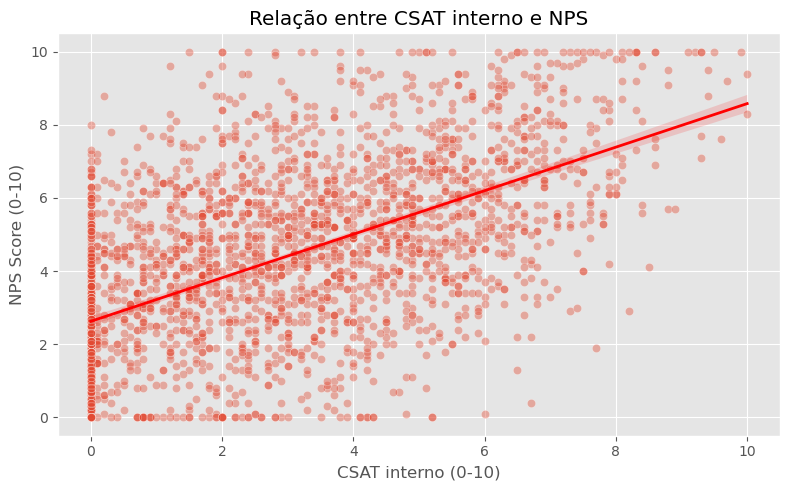

In [85]:
# Scatter plot: CSAT interno vs NPS

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='csat_internal_score', y='nps_score', alpha=0.4)
sns.regplot(data=df, x='csat_internal_score', y='nps_score',
            scatter=False, color='red', line_kws={'linewidth': 2})
plt.title('Relação entre CSAT interno e NPS')
plt.xlabel('CSAT interno (0-10)')
plt.ylabel('NPS Score (0-10)')
plt.tight_layout()
plt.show()

A linha de tendência mostra que para cada ponto ganho no CSAT interno, temos um incremento previsto no NPS, mas a "nuvem" de pontos larga indica que sua operação é inconsistente. Você tem clientes com CSAT 8 dando NPS 2.

In [86]:
# NPS médio para clientes que recompraram vs não recompraram

nps_recompra = df.groupby('repeat_purchase_30d')['nps_score'].agg(['mean','count']).round(2)
nps_recompra.index = ['Não recomprou','Recomprou']
nps_recompra

,mean,count
Não recomprou,3.94,2282
Recomprou,9.01,218


/var/folders/rh/vq3_x16j5c3c0xs3x73_hnlr0000gn/T/ipykernel_57498/3614304268.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=nps_recompra.index, y=nps_recompra['mean'],


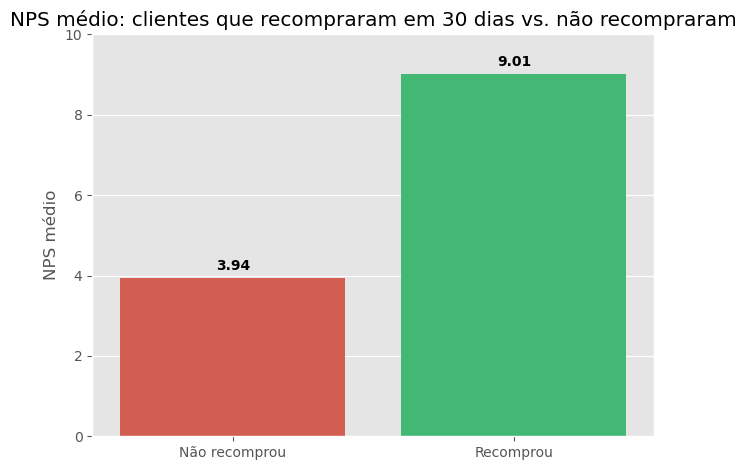

In [87]:
# Visualização da recompra

plt.figure()
ax = sns.barplot(x=nps_recompra.index, y=nps_recompra['mean'],
                 palette=['#e74c3c','#2ecc71'])
for i, v in enumerate(nps_recompra['mean'].values):
    ax.text(i, v + 0.2, f'{v:.2f}', ha='center', fontweight='bold')
plt.title('NPS médio: clientes que recompraram em 30 dias vs. não recompraram')
plt.xlabel('')
plt.ylabel('NPS médio')
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

### Conclusão

- **Recompra em 30 dias** Quem recomprou tem NPS médio de **6,7**,
  quem não recomprou tem NPS médio de **2,4**. Essa é a tradução financeira do problema: detratores
  não voltam a comprar.


## 9. Conclusões, Respostas ao questionamento do desafio




## Principais Achados


**1. O cenário é crítico, mas o problema está mapeado.**
NPS de -80 com 84% de detratores. Não é um problema de "alguns clientes difíceis", é um problema
estrutural na operação que afeta a maioria.

**2. O perfil do cliente NÃO explica o NPS.**
Idade, região e tempo de relacionamento são quase irrelevantes. Isso descarta a hipótese de
segmentação como solução principal.

**3. O atraso na entrega é o maior destruidor de satisfação.**
Não é o tempo absoluto de entrega — é a quebra da promessa. Cliente entregue no prazo tem NPS
médio de 6,86. Cliente com mais de 7 dias de atraso tem NPS zero.

**4. Reclamações e contatos com SAC são o segundo grande fator.**
Indicam que o cliente está "correndo atrás" da empresa. Cada contato a mais empurra o NPS para baixo.

**5. NPS está fortemente ligado à recompra.**
Quem recomprou tem NPS de 6,7. Quem não recomprou tem NPS de 2,4. O NPS é uma métrica antecedente
de receita, não vaidade.

## 1. Entendimento do negócio: nessa primeira etapa, queremos exercitar o seu pensamento analítico, não código. Nos traga a resposta para as seguintes perguntas de negócio:

**● Qual problema de negócio está sendo resolvido?**

Só descobre que o cliente está insatisfeito depois que a experiência ruim já aconteceu, quando a pesquisa de NPS chega. Isso impede a empresa de agir preventivamente, corrigir problemas em tempo real e evitar perda de clientes antes que virem detratores declarados. O problema resolvido é identificar quais fatores operacionais explicam a satisfação do cliente, para monitorá-los em tempo real e agir antes da pesquisa chegar.

**● Por que o NPS é importante para um e-commerce?**

É de 5 a 25 vezes mais caro adquirir um novo cliente, do que reter um atual. Detratores não recompram e não indicam, dobrando o estrago.

**● Quais áreas poderiam se beneficiar desses insights? Exemplos:**

* **Logística:** Ajustar SLAs prometidos no checkout, criar alertas de risco de atraso e priorizar rotas críticas.
* **Atendimento:** Priorizar tickets de pedidos com sinais de risco alto (atraso + múltiplos contatos) e alocar melhor recursos.
* **Produto/UX:** Identificar fricções na jornada (exemplo: promessa de prazo pouco clara, falta de tracking proativo).
* **Pricing/Comercial:** Entender se desconto/parcelamento afetam percepção de valor (na análise, provamos que não afetam — correlação próxima de zero).
* **CRM/Marketing:** Criar campanhas de retenção direcionadas a pedidos em zona de risco antes da pesquisa chegar.

**Além do entendimento do negócio, inclua uma reflexão (não precisa de dados externos obrigatórios): Como o NPS impacta:**

* **Recompra:** Nesta base, clientes que recompraram em 30 dias têm NPS médio de 6,7, contra 2,4 dos que não recompraram (correlação forte de +0,57). Cada ponto perdido é receita futura perdida por churn.
* **Boca a boca:** Detratores afastam ativamente novos clientes. Em e-commerce, onde 70-80% dos consumidores visualizam reviews, um NPS de -80 significa construir ativamente uma reputação negativa, perdendo vendas.
* **Market share em e-commerce:** O setor tem baixíssima fidelidade natural. Market share é conquistado por retenção e indicação. Com um NPS de -80 (abaixo da média de 50-60 do Brasil), a empresa perde participação.

**Quais indicadores de mercado poderiam complementar essa análise? Exemplos: benchmarks de NPS, SLA logístico, concorrência.**

* **Benchmarks de NPS por setor, por exemploTrack.co** Para entender se a nota é crítica para a categoria.
* **SLA logístico do mercado:** Prazo prometido vs. realizado por concorrentes.
* **Taxa de recompra do setor:** % de clientes que voltam em 30/60/90 dias.
* **Share of wallet:** Quanto o cliente compra com a empresa vs. concorrentes.
* **Índice de reclamação (Reclame Aqui, Consumidor.gov):** Para cruzar o NPS com a reputação pública.

---

## 2. Definição da Target: qual é o alvo desse problema de negócio? Nessa segunda etapa queremos uma avaliação de entendimento conceitual, não técnico.

**● Qual variável representa a satisfação do cliente?**

A variável **nps_score**, que é a nota de 0 a 10 dada pelo cliente. A partir dela, derivei os grupos: Detratores (0 a 6), Neutros (7 a 8) e Promotores (9 a 10). O score final é o % Promotores − % Detratores.

**● Por que ela foi escolhida?**

É a medida direta da percepção do cliente, é um padrão de mercado que permite benchmarking e apresenta forte correlação com comportamentos futuros, como a recompra em 30 dias. Além disso, é uma métrica acionável.

**● Em que momento da jornada essa informação é coletada?**

Após o encerramento da jornada de compra

**● Existe algum risco de usar essa variável de forma inadequada?**

* **Viés de resposta:** Apenas clientes nos extremos (muito satisfeitos ou muito insatisfeitos) costumam responder.
* **Viés temporal:** O cliente avalia o último evento (ex: um atraso), ignorando o histórico de boas experiências anteriores.
* **Correlação ≠ Causalidade:** Um fator atrelado ao NPS baixo pode ser apenas sintoma, não a causa raiz.
* **Métrica única:** NPS mede intenção de indicação, não esforço ou satisfação exata. Precisa ser cruzado com outras variaveis
* **Otimizar a métrica, não o cliente:** Tentar "burlar" a pesquisa (dar descontos por notas boas) infla o número, mas não resolve a operação.

---

## 3. Análise Exploratória dos Dados (EDA): realize uma análise exploratória com foco em negócio, não só estatística. Responda:

**● Quais fatores parecem mais críticos para a satisfação?**

Os fatores críticos de destruição são: Atraso na entrega (-0,60), sendo o mais crítico; Número de reclamações (-0,50); e Contatos com SAC (-0,35).

**● O que mais gera detratores?**

* **Atraso na entrega:** Entregas no prazo têm NPS de 6,86. Atrasos de 1-3 dias derrubam para 4,58; de 4-7 dias cai para 2,01; e 8+ dias vai a zero.
* **Reclamações:** Clientes sem reclamações têm NPS de 8,52. Com 5+ reclamações, o NPS fica abaixo de 4. Se o cliente teve problema, mesmo resolvido, dificilmente volta a ser promotor.

**● Existe algum “ponto de ruptura” na experiência do cliente?**

* **3 dias de atraso:** Até 3 dias, o cliente tolera como detrator leve (NPS entre 4 e 5). A partir do 3º dia, o NPS despenca abruptamente.
* **1ª reclamação:** O ato de precisar reclamar derruba o NPS de 8,5 para 7,8 imediatamente. A fricção abaixa a nota, independentemente da resolução.

**● Que tipo de cliente tende a ter NPS mais alto ou mais baixo?**

Pela análise não é não tem um perfil especifico de cliente que influencia a queda do NPS, sendo por faixa de idade ou por região.